# Session 1 : Basics of machine learning with neural networks : fitting potentials

### Neural networks structure and Function Approximation

**Source**: https://openlearninglibrary.mit.edu/assets/courseware/v1/9c36c444e5df10eef7ce4d052e4a2ed1/asset-v1:MITx+6.036+1T2019+type@asset+block/notes_chapter_Neural_Networks.pdf


Neural networks are parametric models designed to approximate complex nonlinear mappings between input and output spaces. From a mathematical perspective, a neural network defines a function $f_{\theta} : \mathbb{R}^n \rightarrow \mathbb{R}^m$ parameterized by a set of variables $\theta = \{W^{(l)}, b^{(l)}\}$, where $W^{(l)}$ and $b^{(l)}$ are the weights and biases associated with layer $l$.

The parameters are optimized using data in order to approximate an unknown target function. Suppose we have a set of observations:

$$
\mathcal{D} =
\left\{
(x_i, y_i)
\right\}_{i=1}^{N}
$$

where:

- $x_i \in \mathbb{R}^n$ are input vectors,
- $y_i \in \mathbb{R}^m$ are target outputs.

The goal is to construct an approximation

$$
f_{\theta}(x) \approx y
$$

that generalizes beyond the training data.


### Architecture of a Feed-Forward Neural Network

![title](neurons.png)

A feed-forward neural network is constructed as a composition of layers:

$$
f_{\theta}(x)=
f^{(L)} \circ f^{(L-1)} \circ \cdots \circ f^{(1)}(x)
$$

where $L$ is the number of layers.

Each layer performs an affine transformation followed by a nonlinear activation:

$$
a^{(l+1)}=
\sigma
\left(
W^{(l)} a^{(l)} + b^{(l)}
\right)
$$

with:

- $a^{(l)}$: activations at layer $l$,
- $W^{(l)}$: weight matrix,
- $b^{(l)}$: bias vector,
- $\sigma$: activation function.

The input layer is defined by

$$
a^{(0)} = x
$$

and the final output is

$$
f_{\theta}(x) = a^{(L)}
$$

### Single Neuron

A single neuron computes:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

followed by a nonlinear transformation

$$
a = \sigma(z)
$$

The nonlinearity is essential. Without activation functions, the composition of layers would reduce to a single linear transformation.

### Activation Functions

Common activation functions include:

- **Sigmoid** : $\sigma(z) = \frac{1}{1 + e^{-z}}$

- **Hyperbolic Tangent**: $\sigma(z) = \tanh(z)$

- **ReLU**: $\sigma(z) = \max(0,z)$

ReLU and related variants are widely used because they mitigate gradient saturation problems encountered with sigmoid-like activations.

---

### A first example:

Fitting the function $f(x)=x^2$ with a simple neural network (no fitting of parameters).

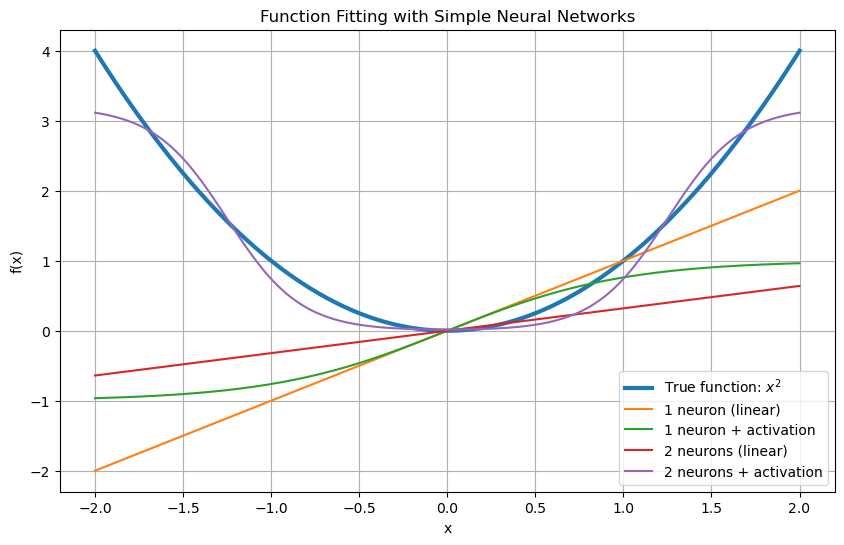

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Generate dataset
# ============================================================

x = np.linspace(-2, 2, 200).reshape(-1,1)

# Target function
y = x**2

# ============================================================
# Model 1:
# One neuron, no activation
#
# y = w*x + b
# ============================================================

def model_linear_1(x):
    w = 1.0; b = 0.0
    return w*x + b

# ============================================================
# Model 2:
# Two neurons, no activation
#
# hidden = W1*x + b1
# output = W2*hidden + b2
#
# ============================================================

def model_linear_2(x):
    W1 = np.array([[2.2, -2.4]]); b1 = np.array([0.0, 0.0])
    W2 = np.array([[-1.6],[-1.6]]); b2 = np.array([0.0])
    return (x @  W1 + b1) @ W2 + b2

# ============================================================
# Model 2:
# One neuron with activation
#
# y = tanh(w*x + b)
# ============================================================

def model_activation_1(x):
    w = 1.0; b = 0.0
    return np.tanh(w*x + b)

# ============================================================
# Model 4:
# Two neurons with activation
#
# hidden = tanh(W1*x + b1)
# output = hidden @ W2 + b2
# ============================================================

def model_activation_2(x):
    W1 = np.array([[2.4, -2.4]]); b1 = np.array([3.0, 3.0])
    W2 = np.array([[-1.6],[-1.6]]); b2 = np.array([3.2])
    h = np.tanh(x @ W1 + b1)
    output = h @ W2 + b2
    return output

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10,6))

# True function
plt.plot(x, y,
         linewidth=3,
         label=r"True function: $x^2$")

# Models
plt.plot(x, model_linear_1(x), label="1 neuron (linear)")
plt.plot(x, model_activation_1(x), label="1 neuron + activation")
plt.plot(x, model_linear_2(x),label="2 neurons (linear)")
plt.plot(x, model_activation_2(x),label="2 neurons + activation")

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title("Function Fitting with Simple Neural Networks")

plt.legend()
plt.grid(True)
plt.show()

### Fitting the neural network parameters

### Datasets : Training set and Validation/Test set

![](dataset.png)

The training set is to fit the network parameters, while the validation or test set is to see if we are overfitting our solution (see below the example)

### Loss Functions

Training consists of minimizing a loss function that quantifies the discrepancy between predictions and target values.

For regression problems, the most common choice is the mean squared error (MSE):

$$
\mathcal{L}(\theta)=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
f_{\theta}(x_i) - y_i
\right|^2
$$

The optimization problem is therefore

$$
\theta^*=
\operatorname*{argmin}_{\theta}
\mathcal{L}(\theta)
$$

### Gradient-Based Optimization

The parameters are optimized iteratively using gradient-based methods such as gradient descent.

Given a learning rate \(\eta\), the update rule is

$$
\theta_{t+1}=
\theta_t-
\eta
\nabla_{\theta}
\mathcal{L}(\theta_t)
$$

Efficient computation of gradients is achieved using the **backpropagation algorithm**, which applies the chain rule recursively through the computational graph.

### Universal Approximation

A fundamental theoretical result is the Universal Approximation Theorem, which states that a sufficiently large neural network with nonlinear activation functions can approximate a broad class of continuous functions arbitrarily well.

Symbolically,

$$
f_{\theta}(x)
\approx
g(x)
$$

for any sufficiently regular target function \(g(x)\), provided the network contains enough parameters.

This property explains why neural networks are effective for modeling highly nonlinear phenomena.


### Neural Networks in Scientific Applications

Neural networks are increasingly important in computational science because they can learn high-dimensional nonlinear relationships directly from data.

Applications include:

- Molecular potential-energy surfaces
- Force-field development
- Quantum chemistry surrogate models
- Spectral prediction
- Dynamical systems
- Inverse problems
- Materials informatics

In many scientific applications, neural networks serve as flexible differentiable approximators for functions that are computationally expensive to evaluate directly.


### Objectives of This Course

In this notebook course, we will:

1. Construct neural networks from first principles
2. Train networks to fit analytical functions
3. Study optimization and convergence
4. Investigate underfitting and overfitting
5. Analyze the role of architecture and hyperparameters
6. Visualize learned representations and predictions

The emphasis will be on building physical and mathematical intuition for how neural networks learn nonlinear functions from data.


### Fitting versus Overfitting: the bigger is not always the better

Fitting with too large polynomials (or neural network) with too few data leads to overfitting solutions with large errors. An example of fitting the $f(x)=x**2$ function with a polynomial of order 2 or a polynomial of order 12.

----

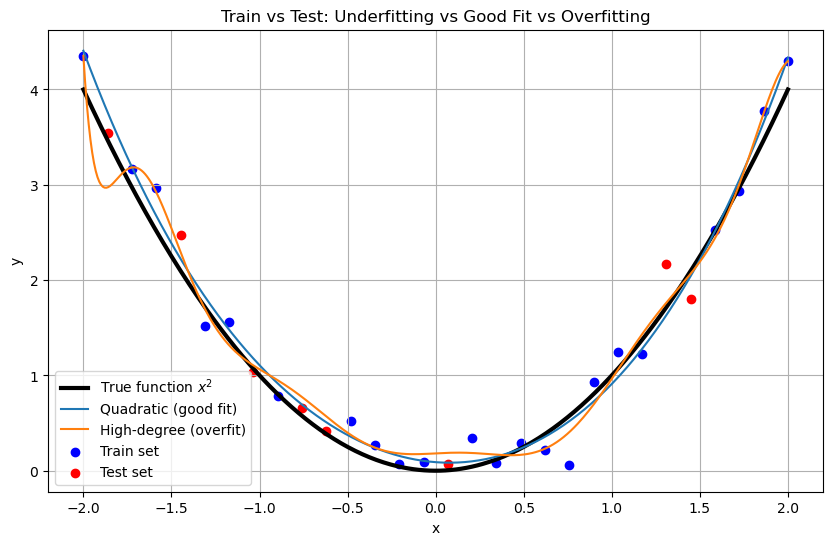

Error on training set:
  Polynomial 2: 0.6819920505541666
  Polynomial 12: 0.4769358107489409
Error on test set:
  Polynomial 2: 0.48039403327863744
  Polynomial 12: 0.6498367433105775


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate true function
# ============================================================

def f(x):
    return x**2

x = np.linspace(-2, 2, 200)
y = f(x)

# ============================================================
# 2. Create dataset (noisy samples)
# ============================================================

np.random.seed(0)

nsize=30

x_data = np.linspace(-2, 2, nsize)
y_data = f(x_data) + 0.2*np.random.randn(len(x_data))

# Train / test split
idx = np.random.permutation(len(x_data))
train_idx = idx[:int(nsize*0.75)]
test_idx  = idx[int(nsize*0.75):]

x_train, y_train = x_data[train_idx], y_data[train_idx]
x_test, y_test   = x_data[test_idx], y_data[test_idx]

# ============================================================
# 3. Fit models of increasing complexity
# ============================================================

# ---- Model 1: quadratic fit (correct complexity)
coef2 = np.polyfit(x_train, y_train, 5)
p2 = np.poly1d(coef2)

# ---- Model 2: high-degree polynomial (overfitting)
coef3 = np.polyfit(x_train, y_train, 12)
p3 = np.poly1d(coef3)

# ============================================================
# 4. Evaluate on smooth grid
# ============================================================

x_plot = np.linspace(-2, 2, 400)

# ============================================================
# 5. Plot everything
# ============================================================

plt.figure(figsize=(10,6))

# True function
plt.plot(x_plot, f(x_plot), 'k', linewidth=3, label="True function $x^2$")

# Predictions
plt.plot(x_plot, p2(x_plot), label="Quadratic (good fit)")
plt.plot(x_plot, p3(x_plot), label="High-degree (overfit)")

# Training data
plt.scatter(x_train, y_train, color="blue", label="Train set")

# Test data
plt.scatter(x_test, y_test, color="red", label="Test set")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train vs Test: Underfitting vs Good Fit vs Overfitting")
plt.legend()
plt.grid(True)

plt.show()

print("Error on training set:")
print("  Polynomial 2:", np.sum((y_train-p2(x_train))**2))
print("  Polynomial 12:", np.sum((y_train-p3(x_train))**2))
print("Error on test set:")
print("  Polynomial 2:",  np.sum((y_test-p2(x_test))**2))
print("  Polynomial 12:", np.sum((y_test-p3(x_test))**2))

# Case 1 : Fitting an arbitrary potential with a neural network

### Imports and dependencies

In this section, we load the core Python libraries required for data handling, machine learning, and visualization.

- **NumPy** (`numpy`):  
  Provides efficient array structures and numerical operations. It is commonly used for preprocessing data and handling input/output arrays.

- **PyTorch** (`torch`, `torch.nn`):  
  PyTorch is the deep learning framework used to build and train neural networks.  
  - `torch` provides the core tensor operations (similar to NumPy, but GPU-compatible).  
  - `torch.nn` contains high-level building blocks for constructing neural network architectures (layers, activation functions, loss functions, etc.).

- **Matplotlib** (`matplotlib.pyplot`):  
  A plotting library used to visualize data, training results, and model predictions. It is especially useful for inspecting how well the neural network reproduces the torsional potential.

In [28]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### Analytic torsional potential

In this section, we define a simple analytical model for a torsional (dihedral) energy profile as a function of the angle φ.

We use a Fourier-like expansion commonly employed in molecular mechanics force fields:

- `torsion_energy(φ)` defines the potential energy as a sum of cosine terms with different periodicities.
- `torsion_grad(φ)` provides the analytical derivative of the energy with respect to φ (i.e., the torque or force).

The parameters:
- **V1, V2, V3** control the amplitude of each periodic contribution.
- Each term corresponds to a different harmonic:
  - 1-fold periodicity (cos φ)
  - 2-fold periodicity (cos 2φ)
  - 3-fold periodicity (cos 3φ)

These coefficients determine the shape of the torsional energy surface and can be freely modified.

#### Important note for students
You are encouraged to:
- change the values of **V1, V2, V3** to see how they affect the energy landscape,
- or replace this functional form entirely with any other expression you want.

This flexibility is important: in this notebook, the neural network will learn to approximate whatever torsional potential you define here.

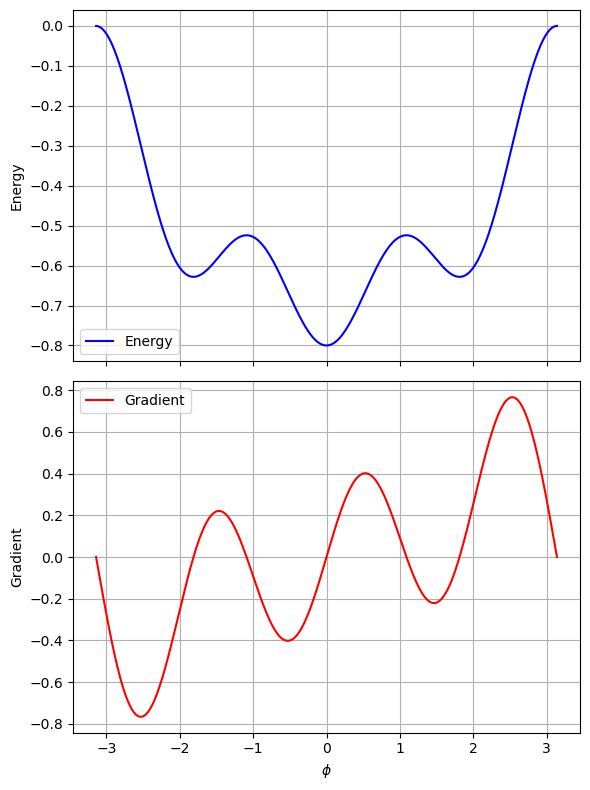

In [29]:

V1, V2, V3 = 0.5, 0.2, 0.3 #User-defined parameters for the potential

def torsion_energy(phi):
    return (
        -0.5 * V1 * (1 + np.cos(phi)) +
        -0.5 * V2 * (1 - np.cos(2 * phi)) +
        -0.5 * V3 * (1 + np.cos(3 * phi))
    )

def torsion_grad(phi):
    return (
        0.5 * V1 * np.sin(phi) +
        - V2 * np.sin(2 * phi) +
        1.5 * V3 * np.sin(3 * phi)
    )

phi_grid = np.linspace(-np.pi, np.pi, 500)

E_true = torsion_energy(phi_grid)
G_true = torsion_grad(phi_grid)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Energy plot
ax1.plot(phi_grid, E_true, label='Energy', color='blue')
ax1.set_ylabel("Energy")
ax1.legend()
ax1.grid(True)

# Gradient plot
ax2.plot(phi_grid, G_true, label='Gradient', color='red')
ax2.set_xlabel(r"$\phi$")
ax2.set_ylabel("Gradient")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Generating training data for the neural network

In this step, we construct the dataset that will be used to train the neural network.

We assume that the true torsional energy function is known (defined above), and we generate synthetic data by sampling random torsion angles φ.

#### Procedure

- We draw **n_samples = 100** random angles uniformly distributed in the interval [-π, π].
- For each angle, we compute the corresponding energy using the analytical function `torsion_energy(φ)`.

This produces a dataset of input-output pairs:
- **Inputs (X):** torsion angles φ
- **Targets (y):** corresponding energies E(φ)

#### Important note for students
You are encouraged to:
- change the n_samples, since it is an analytic function, computing more points is for free

We then reshape the data into column vectors and convert them to `float32` X and y, which is the standard format expected by PyTorch models.

This setup mimics a supervised learning problem where the neural network learns to approximate the underlying potential energy surface.

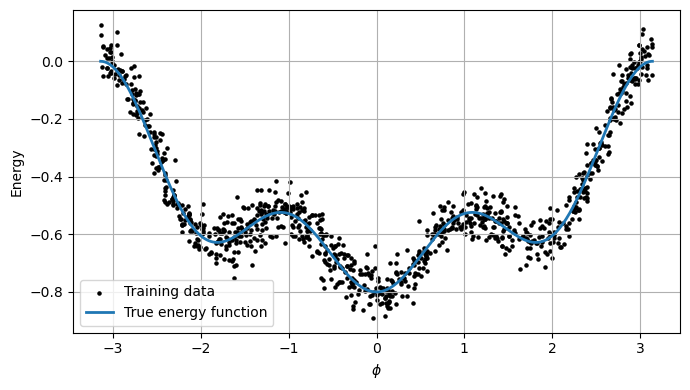

In [30]:
np.random.seed(0)
n_samples = 1000

phi = np.random.uniform(-np.pi, np.pi, n_samples)
E = torsion_energy(phi) 
E = E + 0.05*np.random.randn(len(phi))

X = phi.reshape(-1, 1).astype(np.float32)
y = E.reshape(-1, 1).astype(np.float32)

# Smooth curve for reference
phi_grid = np.linspace(-np.pi, np.pi, 500)
E_grid = torsion_energy(phi_grid)

plt.figure(figsize=(7, 4))

# Training data (scatter)
plt.scatter(X, y, s=5, color="black", label="Training data")
# Continuous function
plt.plot(phi_grid, E_grid, label="True energy function", linewidth=2)

plt.xlabel(r"$\phi$")
plt.ylabel("Energy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Splitting the dataset into training and test sets

To evaluate how well the neural network generalizes, we split the dataset into two parts:

- **Training set (75%)**: used to fit the neural network parameters.
- **Test set (25%)**: used only to evaluate performance after training.

This separation is essential to avoid overfitting, i.e. the model memorizing the training data instead of learning the underlying function.

#### Procedure

- We first randomly shuffle the dataset indices using `np.random.permutation` to ensure that the split is unbiased.
- We then assign:
  - the first 75% of samples to the training set,
  - the remaining samples to the test set.

Finally, we convert the data into PyTorch tensors, which are required for training the neural network.

#### Key idea

- **Training set**: the data the model learns from.
- **Test set**: unseen data used to measure how well the model generalizes.

Train size:  750 out of  1000


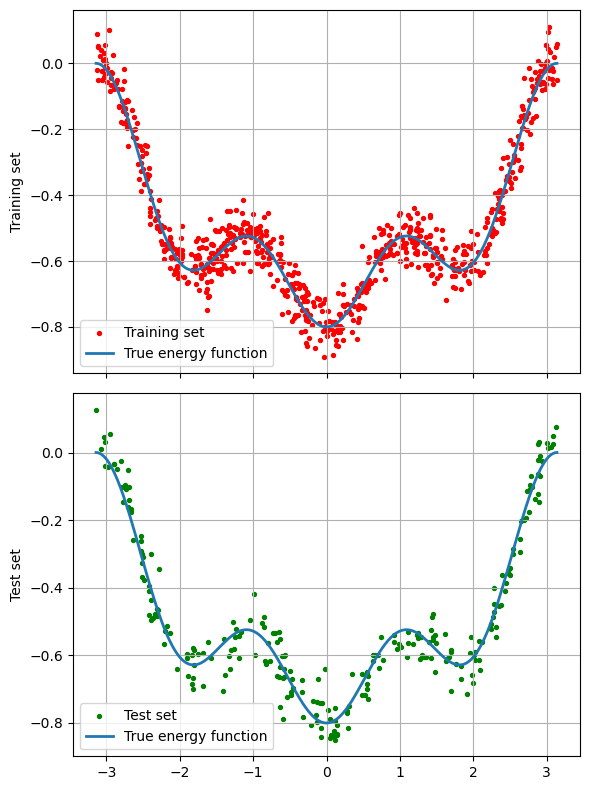

In [31]:
idx = np.random.permutation(n_samples)

train_size = int(0.75 * n_samples)
print("Train size: ",train_size, "out of ",n_samples)

train_idx = idx[:train_size]
test_idx = idx[train_size:]

X_train = torch.tensor(X[train_idx])
y_train = torch.tensor(y[train_idx])
X_test = torch.tensor(X[test_idx])
y_test = torch.tensor(y[test_idx])

# Smooth reference curve
phi_grid = np.linspace(-np.pi, np.pi, 500)
E_grid = torsion_energy(phi_grid)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Training set
ax1.scatter(
    X_train.numpy().flatten(),
    y_train.numpy().flatten(),
    s=8,
    color="red",
    label="Training set"
)
ax1.plot(phi_grid, E_grid, label="True energy function", linewidth=2)
ax1.set_ylabel("Training set")
ax1.legend()
ax1.grid(True)

# Test set
ax2.scatter(
    X_test.numpy().flatten(),
    y_test.numpy().flatten(),
    s=8,
    color="green",
    label="Test set"
)
ax2.plot(phi_grid, E_grid, label="True energy function", linewidth=2)
ax2.set_ylabel("Test set")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


### Neural network model for learning the torsional potential

Here we define a fully connected feedforward neural network (also called a multilayer perceptron, MLP) using PyTorch.

The goal of this model is to approximate the function:

$$
E(\phi) \approx \text{Neural Network}(\phi)
$$

#### Architecture

The network has the following structure:

- **Input layer:** 1 neuron (torsion angle φ)
- **Hidden layer 1:** 30 neurons + ReLU activation
- **Hidden layer 2:** 30 neurons + ReLU activation
- **Output layer:** 1 neuron (predicted energy)

#### Key design choices

- **Fully connected layers (`nn.Linear`)**: each neuron is connected to all neurons in the previous layer.
- **Tanh activation**: introduces non-linearity, allowing the network to learn complex periodic functions like torsional potentials.
- **Small input dimension (1D)**: the model maps a single scalar angle to an energy value.

#### Model creation

We instantiate the model as:

```python
model = TorsionNet()

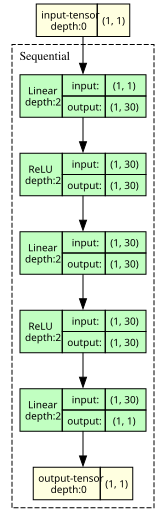

In [32]:
class TorsionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),  # Input layer -> First Hidden Layer: 1 neurons -> 30 neurons.
            nn.ReLU(),         # Activation function for the first Hidden Layer
            nn.Linear(30, 30), # First Hidden -> Second Hidden Layer: 30 neurons -> 30 neurons.
            nn.ReLU(),         # Activation function for the second Hidden Layer
            nn.Linear(30, 1)   # Second Hidden Layer -> Output Layer: 30 neurons -> 1 neuron.
        )

    def forward(self, x):
        return self.net(x)

model = TorsionNet()

from torchview import draw_graph
graph = draw_graph(model, input_size=(1, 1), expand_nested=True)
graph.visual_graph

### Training the neural network

In this section, we train the neural network to learn the mapping between torsion angle φ and its corresponding energy.

#### Components of the training setup

- **Optimizer: Adam**
  - We use the Adam optimizer, a robust gradient-based optimization algorithm that adapts learning rates for each parameter.
  - `lr=1e-3` controls the step size during training.

- **Loss function: Mean Squared Error (MSE)**
  - Measures the difference between predicted energies and true energies:
    $$
    \text{MSE} = \frac{1}{N} \sum (E_{\text{pred}} - E_{\text{true}})^2
    $$
  - The goal of training is to minimize this quantity.

#### Training loop

For each epoch:

1. The model computes predictions:
   - `pred = model(X_train)`

2. The loss is computed between predictions and true values:
   - `loss = loss_fn(pred, y_train)`

3. Gradients are reset:
   - `optimizer.zero_grad()`

4. Backpropagation computes gradients of the loss:
   - `loss.backward()`

5. The optimizer updates the model parameters:
   - `optimizer.step()`

6. The loss is stored for later visualization.

#### Monitoring training

Every 500 epochs, the current loss is printed to track convergence. An **epoch** (also known as training cycle) in machine learning is a term used to describe one complete pass through the entire training dataset by the learning algorithm.

This allows us to verify that the model is progressively learning the torsional energy surface.

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(10000):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(epoch, loss.item())


0 0.16053946316242218
500 0.002602438675239682
1000 0.0024047461338341236
1500 0.0023648161441087723
2000 0.00233654398471117
2500 0.002308768918737769
3000 0.0022800778970122337
3500 0.002261098474264145
4000 0.0022420368622988462
4500 0.0022247189190238714
5000 0.0022420533932745457
5500 0.002207295037806034
6000 0.0022046330850571394
6500 0.0021931794472038746
7000 0.002195318229496479
7500 0.002187487669289112
8000 0.0021821020636707544
8500 0.0021796103101223707
9000 0.002178240567445755
9500 0.002176905982196331


### Evaluating the model on unseen data (test set)

After training, we evaluate the neural network on data that was not used during training.

#### Test loss

We compute the loss on the test set:

- `with torch.no_grad()` disables gradient computation
  - This reduces memory usage and speeds up evaluation
  - It ensures we do not accidentally modify the model

- The test loss measures how well the model generalizes to unseen torsion angles

$$
\text{Test loss} = \text{MSE}(E_{\text{pred}}, E_{\text{true}})
$$

#### Training history

We also plot the loss evolution during training to monitor convergence:

- A decreasing curve indicates successful learning
- A plateau indicates convergence
- Instability may indicate a poor learning rate or model mismatch

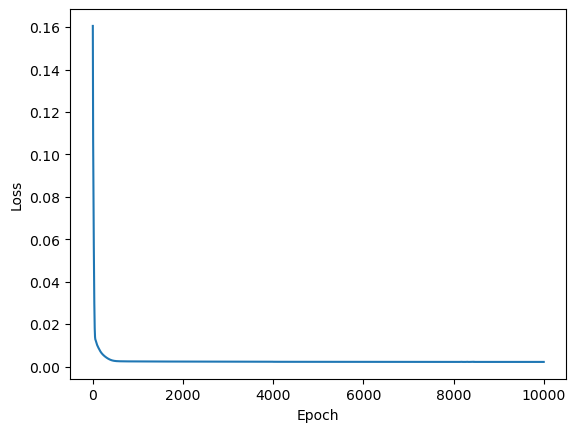

In [34]:
with torch.no_grad():
    test_loss = loss_fn(model(X_test), y_test).item()

test_loss

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### Computing energy gradients with automatic differentiation

In this section, we use PyTorch’s automatic differentiation (autograd) to compute the derivative of the neural network output with respect to its input.

This is essential in molecular modeling, where we are often interested not only in energies but also in their derivatives (forces or torques).

#### Key idea: chain rule

We want to compute:

$$
\frac{dE}{d\phi}
$$

Since the neural network represents a function:

$$
E = \text{NN}(\phi)
$$

PyTorch can automatically compute this derivative using backpropagation.

#### Implementation details

- We enable gradient tracking on the input:
  - `x.requires_grad_(True)`

- We compute the predicted energy:
  - `E_pred = model(x)`

- We use `torch.autograd.grad` to compute:
$$
  \frac{dE}{dx}
$$

- The `.sum()` ensures that gradients are computed for all samples at once.

#### Important note

Even though the network was trained only on energies, it defines a smooth function.  
Therefore, its derivative can be computed analytically via autograd.

#### Comparison

We compare:
- **True energy vs predicted energy**
- **True gradient vs predicted gradient**

This allows us to assess whether the neural network has learned not only the energy surface but also its shape (i.e., its derivatives).

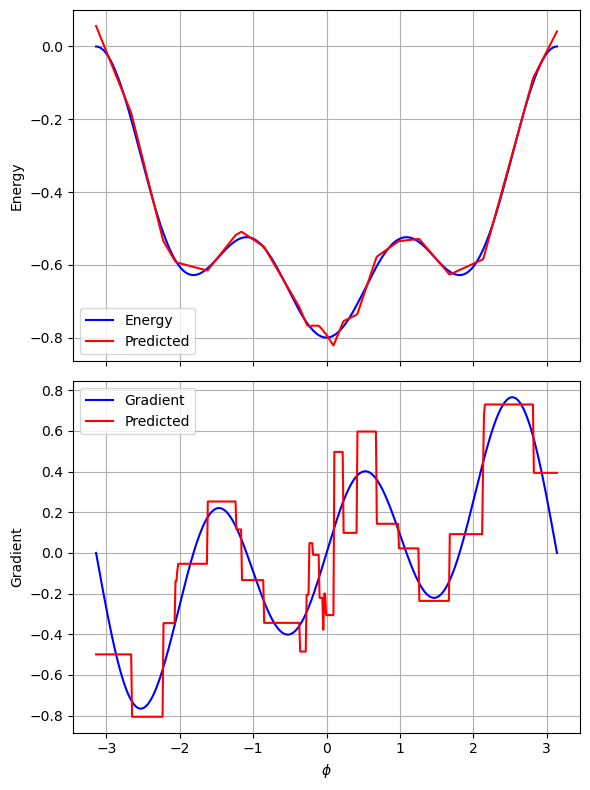

In [35]:
def compute_grad_phi(model, x, phi_tensor):
    # chain rule: dE/dphi = dE/dx * dx/dphi
    x.requires_grad_(True)
    E_pred = model(x)
    grad_x = torch.autograd.grad(E_pred.sum(), x, create_graph=True)[0]

    return grad_x

phi_grid = np.linspace(-np.pi, np.pi, 500)
X_grid = phi_grid.reshape(-1,1).astype(np.float32)

with torch.no_grad():
    E_pred = model(torch.tensor(X_grid)).numpy()

E_true = torsion_energy(phi_grid)

# true quantities
E_true = torsion_energy(phi_grid)
G_true = torsion_grad(phi_grid)

# predicted energy
with torch.no_grad():
    E_pred = model(torch.tensor(X_grid)).numpy()

# predicted gradient via autograd
Xt = torch.tensor(X_grid, requires_grad=True)
dE_E = compute_grad_phi(model, Xt, None).detach().numpy()

# plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Energy plot
ax1.plot(phi_grid, E_true, label='Energy', color='blue')
ax1.plot(phi_grid, E_pred, label='Predicted', color='red')
ax1.set_ylabel("Energy")
ax1.legend()
ax1.grid(True)

# Gradient plot
ax2.plot(phi_grid, G_true, label='Gradient', color='blue')
ax2.plot(phi_grid, dE_E, label='Predicted', color='red')
ax2.set_xlabel(r"$\phi$")
ax2.set_ylabel("Gradient")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Activation functions and differentiability

Neural networks rely on activation functions to introduce non-linearity.

#### Why this matters

Without non-linear activations, the network would be equivalent to a single linear transformation, regardless of depth.

#### Smooth vs non-smooth activations

- **tanh / sigmoid**

  - Defined as :

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

  - Smooth and infinitely differentiable
  - Well-suited for physical problems where derivatives matter (e.g. forces)

- **ReLU (Rectified Linear Unit)**
  - Defined as:
    $$
    \text{ReLU}(x) = \max(0, x)
    $$
  - Not differentiable at $x = 0$
  - Has a sharp “kink” (discontinuity in derivative)

- **Leaky ReLU**

  - Defined as:
$$
\mathrm{LeakyReLU}(x) =
\begin{cases}
x & \text{if } x > 0 \\
\alpha x & \text{if } x \le 0
\end{cases}
$$
  - Introduces a small slope for negative values
  - Removes strict non-differentiability at zero, but still not fully smooth

#### Why this is important here

In this notebook, we compute derivatives of the neural network output with respect to input (forces/torques).

Therefore, smooth activations like **tanh** are preferred because:
- they ensure stable gradients
- they produce physically meaningful smooth energy surfaces

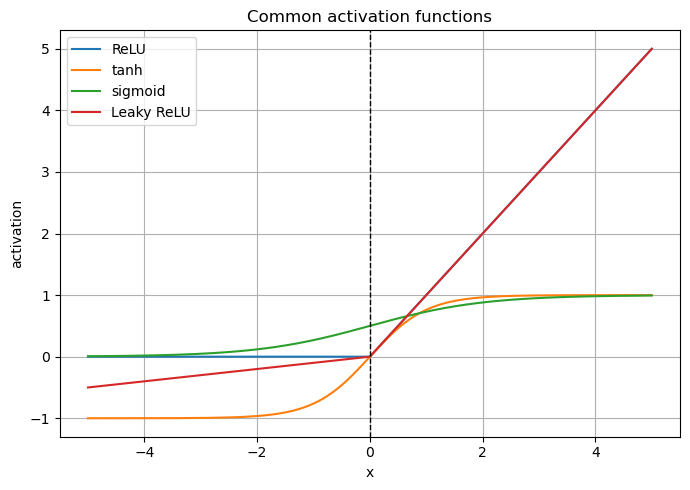

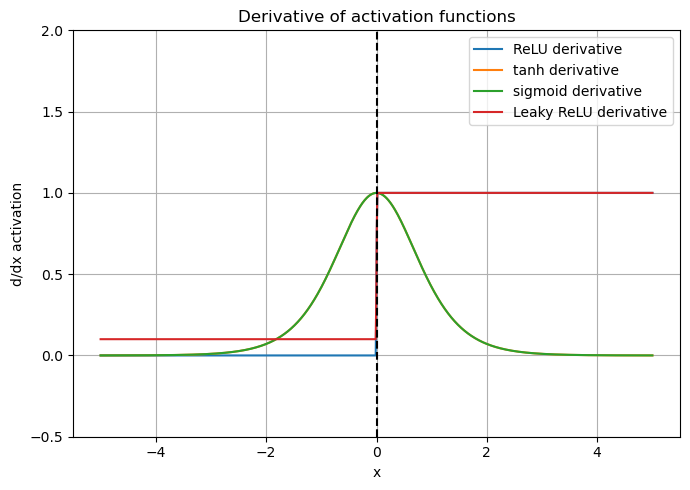

In [36]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)

# Activation functions
relu = np.maximum(0, x)
tanh = np.tanh(x)
sigmoid = 1 / (1 + np.exp(-x))
leaky_relu = np.where(x > 0, x, 0.1 * x)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="tanh")
plt.plot(x, sigmoid, label="sigmoid")
plt.plot(x, leaky_relu, label="Leaky ReLU")

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel("x")
plt.ylabel("activation")
plt.title("Common activation functions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

dx = x[1] - x[0]

relu_grad = np.gradient(relu, dx)
tanh_grad = np.gradient(tanh, dx)
sigmoid_grad = np.gradient(tanh, dx)
leaky_relu_grad = np.gradient(leaky_relu, dx)

plt.figure(figsize=(7, 5))

plt.plot(x, relu_grad, label="ReLU derivative")
plt.plot(x, tanh_grad, label="tanh derivative")
plt.plot(x, sigmoid_grad, label="sigmoid derivative")
plt.plot(x, leaky_relu_grad, label="Leaky ReLU derivative")

plt.axvline(0, color='black', linestyle='--')

plt.ylim(-0.5, 2)
plt.xlabel("x")
plt.ylabel("d/dx activation")
plt.title("Derivative of activation functions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Neural Network Model: `TorsionNet`

In this cell, we define a simple neural network using PyTorch by creating a custom class called `TorsionNet`. This model inherits from `nn.Module`, which is the base class for all neural networks in PyTorch.

#### Architecture

The model is built using `nn.Sequential`, which allows us to stack layers in a straightforward, ordered way:

- **Input layer:** `nn.Linear(1, 30)`  
  Takes a single input feature and maps it to 30 neurons.

- **Hidden layers:**
  - `nn.Tanh()` activation  
  - `nn.Linear(30, 30)`  
  - `nn.Tanh()` activation  
  These layers allow the model to learn non-linear relationships in the data.

- **Output layer:** `nn.Linear(30, 1)`  
  Produces a single output value.

#### Forward Pass

The `forward` method defines how input data flows through the network. Here, it simply passes the input `x` through the sequential model (`self.net`).

#### Model Initialization

Finally, we create an instance of the model:

```python
model = TorsionNet(

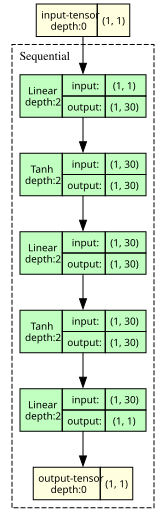

In [37]:
class TorsionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.net(x)

model = TorsionNet()

from torchview import draw_graph
graph = draw_graph(model, input_size=(1, 1), expand_nested=True)
graph.visual_graph

### Training a Neural Network with PyTorch

This cell trains a model using the **Adam optimizer** and evaluates its performance.

---

### 1. Setup: Optimizer and Loss Function
```python
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
```

0 0.22551965713500977
500 0.010982799343764782
1000 0.003908433951437473
1500 0.0024846296291798353
2000 0.002462663222104311
2500 0.0024469736963510513
3000 0.00243408908136189
3500 0.002422645688056946
4000 0.0024113308172672987
4500 0.0024098334833979607
5000 0.0023922384716570377
5500 0.0023737468291074038
6000 0.0023647493217140436
6500 0.0023636913392692804
7000 0.002352556213736534
7500 0.002347386907786131
8000 0.0023420953657478094
8500 0.0023363593500107527
9000 0.002329936483874917
9500 0.0023232188541442156


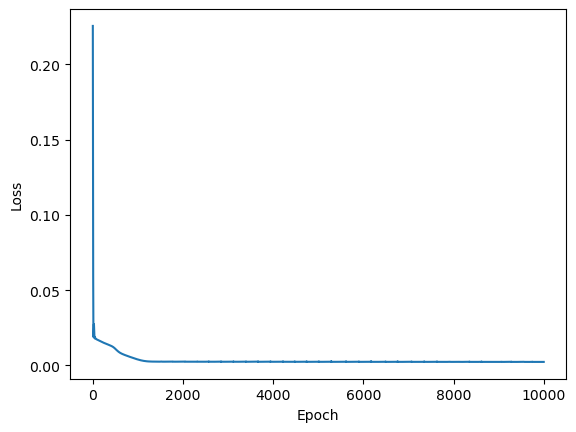

In [38]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(10000):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(epoch, loss.item())

with torch.no_grad():
    test_loss = loss_fn(model(X_test), y_test).item()

test_loss

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In this cell, we can now compare the predicted neural network potential with the real potential. We can do the same for the gradient. The gradient is automatically done for the neural network, since we have analytic functions.

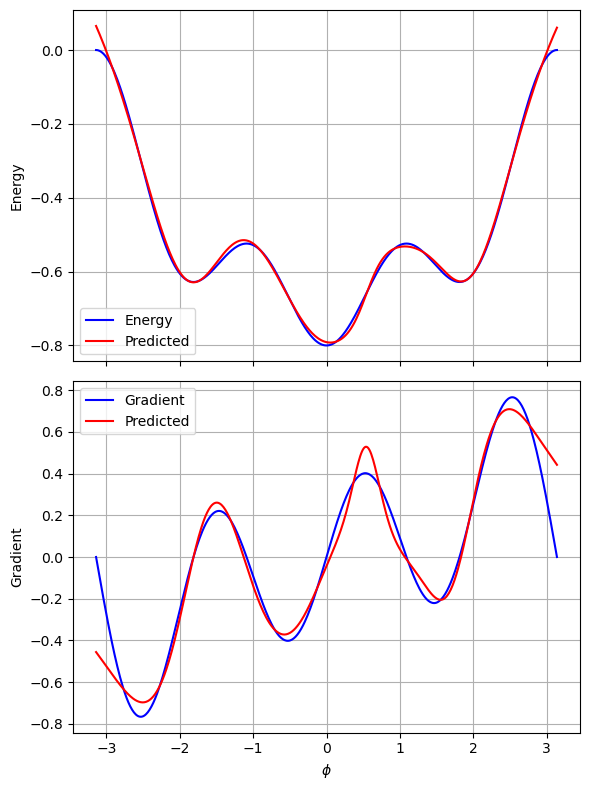

In [39]:
phi_grid = np.linspace(-np.pi, np.pi, 500)
X_grid = phi_grid.reshape(-1,1).astype(np.float32)

with torch.no_grad():
    E_pred = model(torch.tensor(X_grid)).numpy()

E_true = torsion_energy(phi_grid)

# true quantities
E_true = torsion_energy(phi_grid)
G_true = torsion_grad(phi_grid)

# predicted energy
with torch.no_grad():
    E_pred = model(torch.tensor(X_grid)).numpy()

# predicted gradient via autograd
Xt = torch.tensor(X_grid, requires_grad=True)
dE_E = compute_grad_phi(model, Xt, None).detach().numpy()

# plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Energy plot
ax1.plot(phi_grid, E_true, label='Energy', color='blue')
ax1.plot(phi_grid, E_pred, label='Predicted', color='red')
ax1.set_ylabel("Energy")
ax1.legend()
ax1.grid(True)

# Gradient plot
ax2.plot(phi_grid, G_true, label='Gradient', color='blue')
ax2.plot(phi_grid, dE_E, label='Predicted', color='red')
ax2.set_xlabel(r"$\phi$")
ax2.set_ylabel("Gradient")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Case 2: Fitting a Quantum Chemistry Potential with Neural Networks using PyTorch

### Setting up a molecular simulation environment

In Part 2, we move from an analytical torsional potential to a realistic molecular system described using quantum-chemistry-informed force fields.

To do this, we rely on modern molecular simulation tools:

#### OpenFF Toolkit
- Provides a **chemical representation layer** for molecules.
- Allows us to define molecules, atom types, and force field parameters in a standardized way.

#### OpenMM
- A high-performance molecular dynamics engine.
- Used to compute energies, forces, and run simulations.
- Supports GPU acceleration.

#### Force field generation
- `GAFFTemplateGenerator` allows us to use the **General AMBER Force Field (GAFF)** within OpenMM.
- This enables physically realistic molecular mechanics descriptions.

#### PySCF
- `pyscf.gto`
  - Defines molecular geometry for quantum chemistry calculations.

- `pyscf.dft`
  - Performs **Density Functional Theory (DFT)** calculations.
  - Used to compute:
    - electronic energies
    - reference potential energy surfaces
    - optionally forces

#### Key imports

- `Molecule` → molecular structure representation (OpenFF)
- `ForceField` → force field definitions
- `Modeller` → system preparation (solvation, topology building)
- `Simulation`, `VerletIntegrator` → molecular dynamics workflow
- `unit`, `openmm` → physical units and low-level OpenMM API
- `matplotlib` / `numpy` → analysis and visualization tools

#### Conceptual shift

At this stage, we move from:

- **Part 1:** analytical energy functions $$E(\phi)$$

to:

- **Part 2:** physics-based molecular energy models $$E(\mathbf{R})$$

where energies are computed from a force field or quantum-derived potential rather than a hand-defined formula.

In [40]:
from openff.toolkit import Molecule
from openmm.app import ForceField, Modeller, Simulation, NoCutoff
from openmmforcefields.generators import GAFFTemplateGenerator
from openmm import unit, openmm
from openmm import VerletIntegrator
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, dft

### Computing quantum chemistry reference energies with DFT (PySCF)

This function computes molecular energies using **Density Functional Theory (DFT)** via PySCF. These energies serve as high-quality reference labels for training neural network potentials.

---

### What the function does

The function `dft_energy(topology, positions)`:

1. Extracts atomic coordinates from the molecular topology and simulation positions.
2. Converts coordinates into atomic units (Bohr), required by quantum chemistry calculations.
3. Builds a molecular input for PySCF.
4. Runs a DFT calculation to obtain the electronic energy.
5. Converts the energy from Hartree to kJ/mol.

---

### Geometry construction

Each atom is formatted as:

$$
\text{Atom} \quad x \quad y \quad z
$$

This creates the molecular geometry required for quantum chemistry calculations.

---

### PySCF molecular setup

```python
mol = gto.M(
    atom=geom,
    basis="sto-3g",
    unit="Bohr",
    charge=0,
    spin=0
)

In [41]:
def dft_energy(topology,positions,xyzfile=None):
    geom = []
    coords = positions.value_in_unit(unit.angstrom)
    for atom, c in zip(topology.atoms(), coords):
        geom.append(f"{atom.element.symbol} {c[0]} {c[1]} {c[2]}")
    geom="\n".join(geom)
    mol = gto.M(
        atom=geom,
        basis="6-31g(d)",
        unit="Angstrom",
        charge=0,
        spin=0,
        verbose=0
    )
    mf = dft.RKS(mol)
    mf.xc = "b3lyp"
    return mf.kernel() * 2625.5  # Hartree → kJ/mol

### Constructing and minimizing a molecular mechanics system

In this section, we build a full molecular mechanics model starting from a simple chemical representation (SMILES), assign a force field, and perform an energy minimization. This defines the physical energy function that will later be used to generate data for machine learning models.

The goal is to go from a chemical description of a molecule to a physically consistent 3D structure obtained by minimizing a potential energy function.

---

### Molecule definition (SMILES → molecular graph)

```python
mol = Molecule.from_smiles("C=CC=O")

In [42]:
mol = Molecule.from_smiles("C=CC=O")
mol.generate_conformers(n_conformers=1)
gaff = GAFFTemplateGenerator(molecules=mol, forcefield="gaff-2.1")
ff = ForceField()
ff.registerTemplateGenerator(gaff.generator)
topology = mol.to_topology().to_openmm()
positions = mol.conformers[0].to_openmm()
modeller = Modeller(topology, positions)

### Constructing a molecular mechanics system and adding a custom torsional potential

In this section, we define the physical energy model used to describe the molecule. This includes a standard molecular mechanics force field and an additional user-defined torsional restraint.

---

#### 1 — Build the molecular system for acrolein with GAFF forcefield

We first create a molecular mechanics system from a topology and a force field.

```python
system = ff.createSystem(modeller.topology, nonbondedMethod=NoCutoff)
```
####  2 — Define a restrain torsional potential and add it to GAFF

We define a harmonic restraint on a dihedral angle:

```python
restr = openmm.CustomTorsionForce("k*(theta-theta0)^2")
```

#### 3 — Choose the torsion and parameters
We define the atoms forming the dihedral:

```python
TORSION = (0,1,2,3)
```
The initial parameters are $k=100.0 \frac{kJ}{mol\cdot rad^2}$ and $\theta_0=-\pi\ rad$

#### 4 — Minimize the system with GAFF + restrain using OpenMM

In [43]:
#1. Build molecular system
system = ff.createSystem(modeller.topology, nonbondedMethod=NoCutoff)

#2. Define restrain potential
restr = openmm.CustomTorsionForce("k*(theta-theta0)^2")
restr.addPerTorsionParameter("theta0")
restr.addPerTorsionParameter("k")

#3. Choose torsion and parameters
TORSION = (0,1,2,3)
theta0 = -np.pi * unit.radian
k = 70.0 * unit.kilojoule_per_mole/unit.radian**2
restr.addTorsion(*TORSION, [theta0, k])
system.addForce(restr)

#4. Minimize the system with GAFF + restrain
integrator = VerletIntegrator(1.0 * unit.femtoseconds)
sim = Simulation(modeller.topology, system, integrator)
sim.context.setPositions(positions)
sim.minimizeEnergy(tolerance=0.001)

In [44]:
import py3Dmol

# extract positions after minimization
state = sim.context.getState(getPositions=True)
pos = state.getPositions()
sim.context.setPositions(pos)

# convert OpenMM positions to xyz string
xyz = f"{len(pos)}\nminimized structure\n"
for i, atom in enumerate(modeller.topology.atoms()):
    p = pos[i].value_in_unit(unit.angstrom)
    xyz += f"{atom.element.symbol} {p[0]} {p[1]} {p[2]}\n"
print(xyz)
view = py3Dmol.view(width=400, height=300)
view.addModel(xyz, "xyz")
view.setStyle({"stick": {}})
view.zoomTo()
view.show()

8
minimized structure
C -1.240990236401558 0.037070552352815866 0.12141475453972816
C 0.05635929759591818 0.20854001864790916 0.460723452270031
C 1.1794132739305496 -0.1771630346775055 -0.4301687330007553
O 2.346319556236267 -0.022173840552568436 -0.12328911572694778
H -1.5318186581134796 -0.3979332000017166 -0.8341554552316666
H -2.0431621372699738 0.3304487466812134 0.797409787774086
H 0.3380059078335762 0.6438241899013519 1.4172066748142242
H 0.8958730101585388 -0.6226134300231934 -1.4091414213180542



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Generating a torsional energy dataset via constrained relaxation

This code generates a supervised learning dataset that maps a dihedral angle to its corresponding molecular energy. The goal is to learn a smooth potential energy surface of the form:

$$
\phi \rightarrow E(\phi)
$$

where $\phi$ is a torsional (dihedral) angle and $E$ is the energy of the molecule after structural relaxation under that constraint.

We begin by fixing the random seed for reproducibility and defining a set of uniformly spaced torsional angles spanning the full periodic range from $-\pi$ to $\pi$. This discretization defines the sampling grid of the reaction coordinate.

For each angle, the torsional restraint in the molecular mechanics model is updated so that the dihedral is biased toward the current target value. This is done by modifying the equilibrium angle of a harmonic potential of the form:

$$
V(\theta) = k(\theta - \theta_0)^2
$$

After applying the updated restraint, the system is subjected to energy minimization. Importantly, only the selected dihedral is constrained: all other internal degrees of freedom (bond lengths, bond angles, and unconstrained torsions) are allowed to relax. This produces a relaxed configuration consistent with the imposed torsional constraint rather than a rigidly enforced geometry.

Once the structure is minimized, the atomic coordinates are extracted and a reference energy is computed using a higher-level electronic structure method (`dft_energy`). This ensures that the target values correspond to a more accurate description of the electronic energy surface rather than the underlying force field used during relaxation. Each iteration therefore produces a single labeled datapoint consisting of the torsional angle and its associated relaxed energy.

The resulting arrays are finally reshaped into machine-learning compatible formats, producing input features $X = \phi$ and targets $y = E(\phi)$, both stored as float32 vectors.

**Important note:** this procedure is computationally expensive because it performs one full structural relaxation followed by one DFT-level energy evaluation per sampled angle. The current choice of sampling (72 points) is a compromise between resolution and cost. You may safely increase the number of samples to obtain a smoother and more accurate potential energy surface, but this will scale linearly in computational cost, since each additional point requires a full constrained minimization and a DFT energy calculation.

In [45]:
n_samples = 72

phi = np.linspace(-np.pi, np.pi, n_samples, endpoint=False)
E=[]
xyz_mov = ""
icount=0
k = 100.0 * unit.kilojoule_per_mole/unit.radian**2
for angle in phi:  
    # ---- GAFF part ----
    restr.setTorsionParameters(
        0, *TORSION, [angle * unit.radian, k]
    )
    restr.updateParametersInContext(sim.context)
    sim.minimizeEnergy(tolerance=0.001)
    state = sim.context.getState(getPositions=True)
    pos = state.getPositions()
    E.append(dft_energy(modeller.topology,pos))
    sim.context.setPositions(pos)

    # convert OpenMM positions to xyz string
    xyz_mov += f"{len(pos)}\nminimized structure {angle}\n"
    for i, atom in enumerate(modeller.topology.atoms()):
        p = pos[i].value_in_unit(unit.angstrom)
        xyz_mov += f"{atom.element.symbol} {p[0]} {p[1]} {p[2]}\n"

    print(icount,"Angle: ",angle*unit.radian, "Energy:", E[icount]*unit.kilojoule_per_mole)
    icount +=1
X = phi.reshape(-1,1).astype(np.float32)
y = np.array(E).reshape(-1, 1).astype(np.float32)
np.savetxt("torsion_scan_dft.dat", np.column_stack((phi, E)), header="phi energy")

0 Angle:  -3.141592653589793 rad Energy: -503853.6119041368 kJ/mol
1 Angle:  -3.0543261909900767 rad Energy: -503853.52118142165 kJ/mol
2 Angle:  -2.9670597283903604 rad Energy: -503853.2468070695 kJ/mol
3 Angle:  -2.8797932657906435 rad Energy: -503852.79434090236 kJ/mol
4 Angle:  -2.792526803190927 rad Energy: -503852.14908668806 kJ/mol
5 Angle:  -2.705260340591211 rad Energy: -503851.31432347104 kJ/mol
6 Angle:  -2.6179938779914944 rad Energy: -503850.2737029876 kJ/mol
7 Angle:  -2.5307274153917776 rad Energy: -503849.02918818896 kJ/mol
8 Angle:  -2.443460952792061 rad Energy: -503847.56694411294 kJ/mol
9 Angle:  -2.356194490192345 rad Energy: -503845.8711315614 kJ/mol
10 Angle:  -2.2689280275926285 rad Energy: -503843.92797981465 kJ/mol
11 Angle:  -2.181661564992912 rad Energy: -503841.72459096945 kJ/mol
12 Angle:  -2.0943951023931957 rad Energy: -503839.2340735626 kJ/mol
13 Angle:  -2.007128639793479 rad Energy: -503836.442729375 kJ/mol
14 Angle:  -1.9198621771937625 rad Energy: -

In [46]:
view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(xyz_mov)
view.setStyle({"stick": {}})
view.zoomTo()
view.animate({'loop': "forward"})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Plot the training set

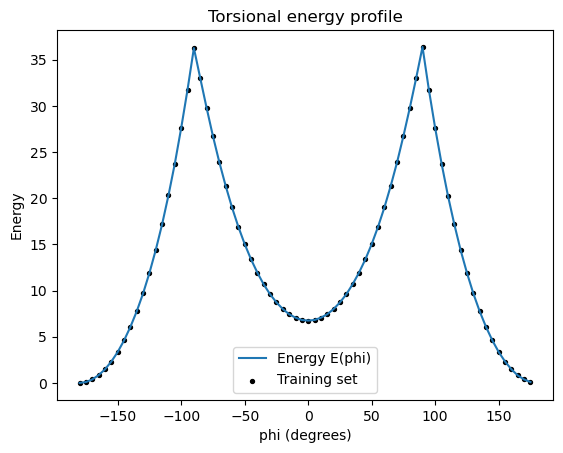

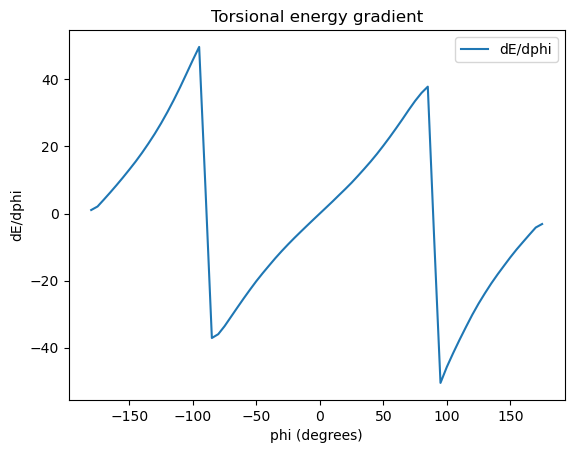

In [47]:
# --- numerical gradient dE/dphi ---
dphi = phi[1] - phi[0]
dE_dphi = np.gradient(E, dphi)

# --- plot energy and gradient ---
plt.figure()
plt.plot(np.rad2deg(phi), y-np.min(y), label="Energy E(phi)")
plt.scatter(
    np.rad2deg(phi),
    y-np.min(y),
    s=8,
    color="black",
    label="Training set"
)
plt.xlabel("phi (degrees)")
plt.ylabel("Energy")
plt.legend()
plt.title("Torsional energy profile")
plt.show()

plt.figure()
plt.plot(np.rad2deg(phi), dE_dphi, label="dE/dphi")
plt.xlabel("phi (degrees)")
plt.ylabel("dE/dphi")
plt.legend()
plt.title("Torsional energy gradient")
plt.show()

Train size:  52 out of  72


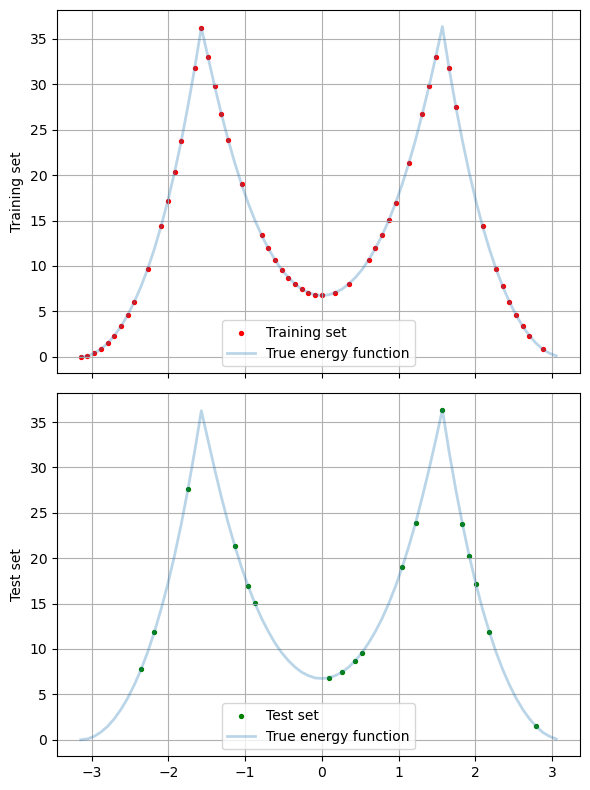

In [48]:
idx = np.random.permutation(n_samples-2)
train_size = int(0.75 * (n_samples-2))
print("Train size: ",train_size, "out of ",n_samples)

train_idx = idx[:train_size]
test_idx = idx[train_size:]

X_train = torch.tensor(X[train_idx])
y_train = torch.tensor(y[train_idx])-np.min(y)
X_test = torch.tensor(X[test_idx])
y_test = torch.tensor(y[test_idx])-np.min(y)

# plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Training set
ax1.scatter(
    X_train.numpy().flatten(),
    y_train.numpy().flatten(),
    s=8,
    color="red",
    label="Training set"
)
ax1.plot(phi, y-np.min(y), alpha=0.3, label="True energy function", linewidth=2)
ax1.set_ylabel("Training set")
ax1.legend()
ax1.grid(True)

# Test set
ax2.scatter(
    X_test.numpy().flatten(),
    y_test.numpy().flatten(),
    s=8,
    color="green",
    label="Test set"
)
ax2.plot(phi, y-np.min(y), alpha=0.3, label="True energy function", linewidth=2)
ax2.set_ylabel("Test set")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


TorsionNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=1, bias=True)
  )
)


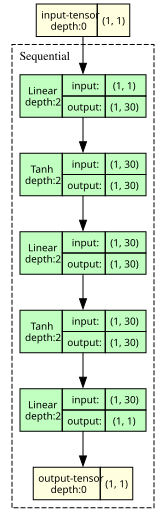

In [145]:
class TorsionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.net(x)

model = TorsionNet()

print(model)

from torchview import draw_graph
graph = draw_graph(model, input_size=(1, 1), expand_nested=True)
graph.visual_graph

In [146]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(10000):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(epoch, loss.item())


0 289.92218017578125
500 73.37975311279297
1000 58.19544982910156
1500 57.40204620361328
2000 57.21717071533203
2500 57.1143798828125
3000 57.04122543334961
3500 56.990623474121094
4000 56.95650100708008
4500 56.932796478271484
5000 56.91568374633789
5500 56.903202056884766
6000 56.893882751464844
6500 56.88663864135742
7000 56.88130569458008
7500 56.877376556396484
8000 56.874202728271484
8500 56.871559143066406
9000 56.86935806274414
9500 56.867591857910156


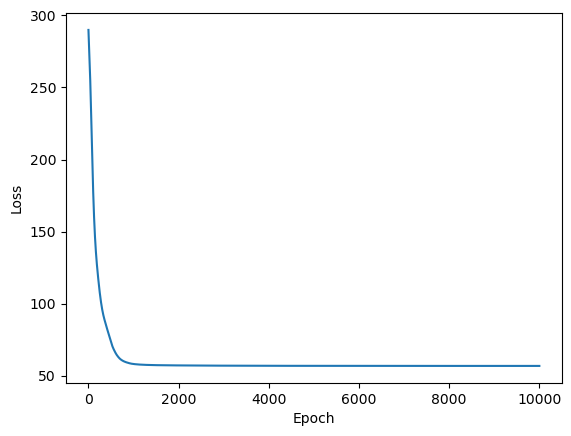

51.06001663208008

In [147]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

with torch.no_grad():
    test_loss = loss_fn(model(X_test), y_test).item()

test_loss

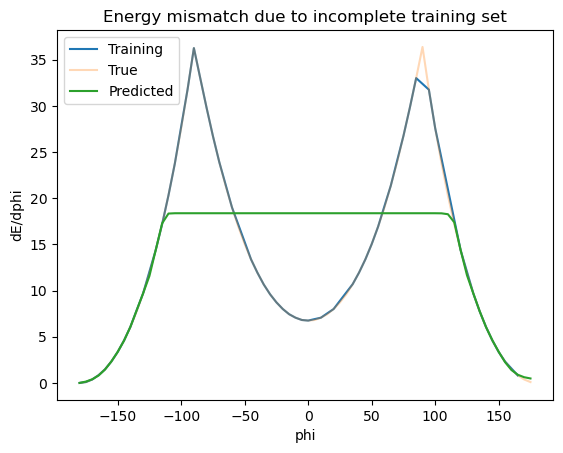

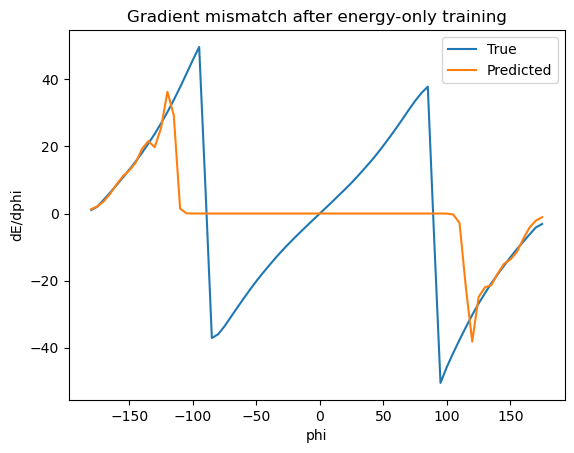

In [148]:
X_grid = phi.reshape(-1,1).astype(np.float32)

with torch.no_grad():
    E_pred = model(torch.tensor(X_grid)).numpy()

plt.figure()
plt.plot(np.rad2deg(phi[np.sort(train_idx)]),y[np.sort(train_idx)]-np.min(y), label='Training')
plt.plot(np.rad2deg(phi),y-np.min(y), alpha=0.3,label='True')
plt.plot(np.rad2deg(phi),E_pred-np.min(E_pred), label='Predicted')
plt.xlabel('phi')
plt.ylabel('dE/dphi')
plt.legend()
plt.title('Energy mismatch due to incomplete training set')
plt.show()

dphi = phi[1] - phi[0]
dE_dphi = np.gradient(E, dphi)

# predicted gradient via autograd
Xt = torch.tensor(X_grid, requires_grad=True)
dE_E = compute_grad_phi(model, Xt, None).detach().numpy()

plt.figure()
plt.plot(np.rad2deg(phi),dE_dphi, label='True')
plt.plot(np.rad2deg(phi),dE_E, label='Predicted')
plt.xlabel('phi')
plt.ylabel('dE/dphi')
plt.legend()
plt.title('Gradient mismatch after energy-only training')
plt.show()

### How would you improve the fitting further?